In [1]:
import pandas as pd
import re # For Regular Expressions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /Users/tekabe/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv('Data/raw/complaints.csv', low_memory=False)

print(f"Dataset loaded successfully. Shape: {df.shape}")
print(df.head(2))

Dataset loaded successfully. Shape: (9609797, 18)
  Date received                                            Product  \
0    2025-06-20  Credit reporting or other personal consumer re...   
1    2025-06-20                                    Debt collection   

               Sub-product                                 Issue  \
0         Credit reporting  Incorrect information on your report   
1  Telecommunications debt     Attempts to collect debt not owed   

                             Sub-issue Consumer complaint narrative  \
0  Information belongs to someone else                          NaN   
1                    Debt is not yours                          NaN   

                             Company public response  \
0                                                NaN   
1  Company can't verify or dispute the facts in t...   

                                        Company State ZIP code Tags  \
0           Experian Information Solutions Inc.    FL    32092  NaN   
1  Easter

In [3]:
print(df)

        Date received                                            Product  \
0          2025-06-20  Credit reporting or other personal consumer re...   
1          2025-06-20                                    Debt collection   
2          2025-06-20  Credit reporting or other personal consumer re...   
3          2025-06-20  Credit reporting or other personal consumer re...   
4          2025-06-20  Credit reporting or other personal consumer re...   
...               ...                                                ...   
9609792    2016-09-08                                   Credit reporting   
9609793    2022-06-06  Credit reporting, credit repair services, or o...   
9609794    2016-07-14                                   Credit reporting   
9609795    2014-03-03                                   Credit reporting   
9609796    2014-11-10                                   Credit reporting   

                     Sub-product  \
0               Credit reporting   
1        Teleco

In [6]:

# --- EDA: Check for Missing/Empty Feedback ---
print("\n--- EDA: Missing/Empty Feedback ---")
# Count explicit NaNs (if any)
print(f"NaN count: {df['Consumer complaint narrative'].isnull().sum()}")
# Count empty strings (often more common in text data)
print(f"Empty string count: {(df['Consumer complaint narrative'] == '').sum()}")


--- EDA: Missing/Empty Feedback ---
NaN count: 6629041
Empty string count: 0


In [8]:

# --- EDA: Distribution of Products ---
print("\n--- EDA: Product Distribution ---")
print(df['Product'].value_counts())


--- EDA: Product Distribution ---
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                      

In [10]:
# --- EDA: Calculate and visualize word count (simple for demo) ---
df['word_count'] = df['Consumer complaint narrative'].apply(lambda x: len(str(x).split()) if str(x).strip() else 0)
print("\n--- EDA: Word Count Distribution ---")
print(df['word_count'].describe())


--- EDA: Word Count Distribution ---
count    9.609797e+06
mean     5.515649e+01
std      1.495169e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: word_count, dtype: float64


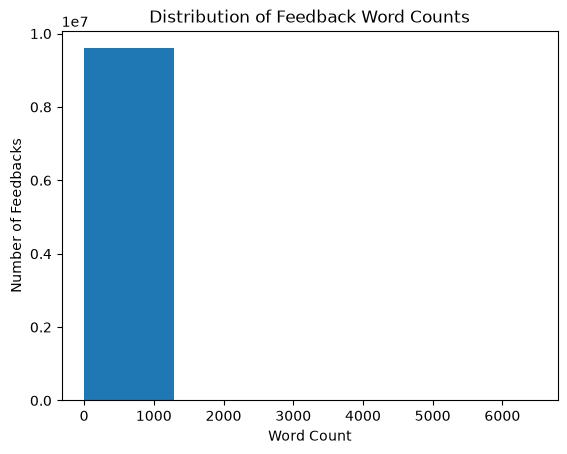

In [11]:
import matplotlib.pyplot as plt
plt.hist(df['word_count'], bins=5)
plt.title('Distribution of Feedback Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Number of Feedbacks')
plt.show()

In [13]:
# --- Preprocessing Step 1: Handle Missing/Empty Feedback ---
print("\n--- Preprocessing: Removing Empty Feedback ---")

# 1. Drop rows where 'Consumer complaint narrative' is NaN/Null
df_cleaned = df[df['Consumer complaint narrative'].notna()].copy()

# 2. Safety check: Also drop rows that are technically text but just empty strings or whitespace
df_cleaned = df_cleaned[df_cleaned['Consumer complaint narrative'].str.strip() != ''].copy()

print(f"Original rows: {len(df):,}")
print(f"Rows after removing empty/NaN: {len(df_cleaned):,}")
print(df_cleaned[['Complaint ID', 'Consumer complaint narrative']].head())


--- Preprocessing: Removing Empty Feedback ---
Original rows: 9,609,797
Rows after removing empty/NaN: 2,980,756
       Complaint ID                       Consumer complaint narrative
76         12351447  XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX Apt XX...
359        12203565  Subject : Dispute of Unauthorized Hard Inquiri...
11499      14089944  I signed a purchase agreement with Lennar Corp...
11973      14080390  After checking my report, I found numerous acc...
12237      14069121  A XXXX XXXX card was opened under my name by a...


In [14]:
# --- Preprocessing Step 2: Filter for Target Products ---
print("\n--- Preprocessing: Filtering for Target Products ---")

# Let's verify the exact names the CFPB uses by listing all unique products
print("Available products in current dataset:")
print(df_cleaned['Product'].unique())

# Define the targeted products based on the exact CFPB names
target_products = [
    'Credit card or prepaid card', # CFPB groups Credit Cards here in newer data
    'Credit card',                 # Used in older data rows
    'Consumer Loan',               # CFPB often labels personal loans under this or 'Payday loan, title loan, personal loan'
    'Payday loan, title loan, personal loan',
    'Savings account',
    'Checking or savings account',
    'Money transfer, virtual currency, or money service',
    'Money transfers'
]

# Apply the filter
df_filtered = df_cleaned[df_cleaned['Product'].isin(target_products)].copy()

print(f"\nRows before product filter: {len(df_cleaned):,}")
print(f"Rows after product filter: {len(df_filtered):,}")


--- Preprocessing: Filtering for Target Products ---
Available products in current dataset:
<StringArray>
[                         'Credit reporting or other personal consumer reports',
                                                                     'Mortgage',
                                                                  'Credit card',
                                                  'Checking or savings account',
                                                              'Debt collection',
                                                        'Vehicle loan or lease',
                      'Payday loan, title loan, personal loan, or advance loan',
                           'Money transfer, virtual currency, or money service',
                                                                 'Student loan',
                                                                 'Prepaid card',
                                                    'Debt or credit management',
 '


--- Preprocessing: Narrative Word Count Analysis ---

Word Count Statistics for Targeted Products:
count    437799.000000
mean        204.880160
std         226.981896
min           1.000000
25%          82.000000
50%         136.000000
75%         254.000000
max        6469.000000
Name: word_count, dtype: float64

[Outlier Check] Complaints with 5 or fewer words: 443
[Outlier Check] Complaints with 1000 or more words: 5,082

Example of a very short complaint: "This inquiry was not me"


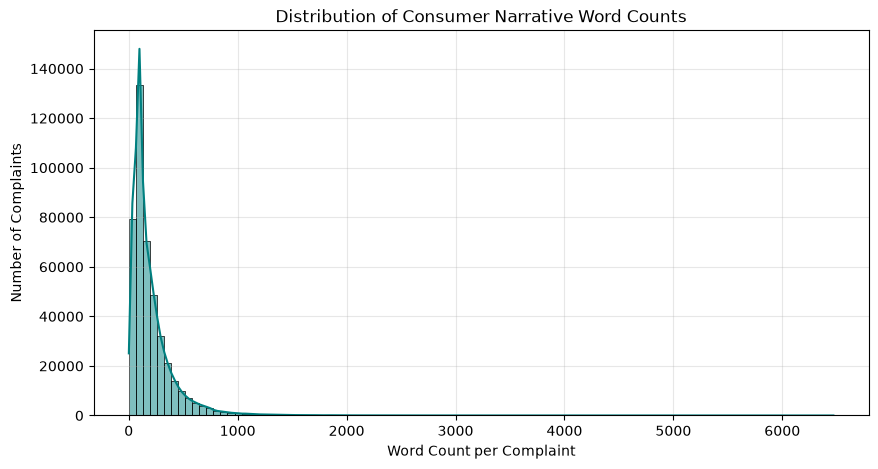

In [15]:
# --- Preprocessing Step 3: Word Count Analysis & Outliers ---
print("\n--- Preprocessing: Narrative Word Count Analysis ---")

# 1. Calculate word counts for the filtered dataset
df_filtered['word_count'] = df_filtered['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

# 2. Get statistical summary metrics
print("\nWord Count Statistics for Targeted Products:")
print(df_filtered['word_count'].describe())

# 3. Identify and flag outliers (very short vs very long)
# You can define thresholds based on your metrics, let's look at extremes:
short_threshold = 5
long_threshold = 1000

short_complaints = df_filtered[df_filtered['word_count'] <= short_threshold]
long_complaints = df_filtered[df_filtered['word_count'] >= long_threshold]

print(f"\n[Outlier Check] Complaints with {short_threshold} or fewer words: {len(short_complaints):,}")
print(f"[Outlier Check] Complaints with {long_threshold} or more words: {len(long_complaints):,}")

# Let's take a quick look at a short outlier example
if len(short_complaints) > 0:
    print(f"\nExample of a very short complaint: \"{short_complaints['Consumer complaint narrative'].iloc[0]}\"")

# 4. Generate the Visualization Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Using a log scale on the Y-axis since the difference between high and low frequencies is massive
sns.histplot(df_filtered['word_count'], bins=100, kde=True, color='teal')
plt.title('Distribution of Consumer Narrative Word Counts')
plt.xlabel('Word Count per Complaint')
plt.ylabel('Number of Complaints')
plt.grid(True, alpha=0.3)

# Save the plot image locally in your VS Code directory
plt.savefig('narrative_word_count_distribution.png', dpi=300)
plt.show()

In [19]:
# --- Preprocessing Step 4: Optimized Advanced Text Normalization ---
print("\n--- Preprocessing: Advanced Text Normalization ---")

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure resources are downloaded
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# 1. Quick lowercase and non-alphanumeric cleanup using fast Pandas vectorization
print("Step 1/3: Cleaning special characters and converting to lowercase...")
clean_series = df_filtered['Consumer complaint narrative'].str.lower()
clean_series = clean_series.str.replace(r'[^a-z0-9\s]', '', regex=True)

# 2. Boilerplate removal
print("Step 2/3: Stripping common boilerplate templates...")
boilerplates = [
    r"i am writing to file a complaint (about|against)?",
    r"to whom it may concern",
    r"dear cfpb",
    r"please note that",
    r"x{2,}" # Removes masked sequences like XXXX
]
for pattern in boilerplates:
    clean_series = clean_series.str.replace(pattern, "", regex=True)

# Define a lighter function for token/lemma/stopwords
def quick_normalize(text):
    if not text:
        return ""
    # Split by spaces (faster than word_tokenize for clean alphanumeric text)
    tokens = text.split()
    
    # Filter stopwords and apply noun + verb lemmatization in a single pass
    cleaned_tokens = [
        lemmatizer.lemmatize(lemmatizer.lemmatize(t, pos='v'), pos='n')
        for t in tokens if t not in stop_words
    ]
    return " ".join(cleaned_tokens)

# 3. Apply the lighter loop
print("Step 3/3: Lemmatizing and filtering stopwords (running optimized loop)...")
df_filtered['normalized_complaint'] = clean_series.apply(quick_normalize)

# Drop any rows that became completely empty after removing boilerplate/stopwords
df_filtered = df_filtered[df_filtered['normalized_complaint'].str.strip() != ""]

print(f"\n--- Processing Complete! Final rows ready for RAG: {len(df_filtered):,} ---")
print(df_filtered[['Consumer complaint narrative', 'normalized_complaint']].head(2))

# Save this processed data to a new CSV file so you don't have to run this long process again!
df_filtered.to_csv('processed_rag_data.csv', index=False)
print("Saved final output to 'processed_rag_data.csv'")


--- Preprocessing: Advanced Text Normalization ---
Step 1/3: Cleaning special characters and converting to lowercase...


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tekabe/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/tekabe/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Step 2/3: Stripping common boilerplate templates...
Step 3/3: Lemmatizing and filtering stopwords (running optimized loop)...

--- Processing Complete! Final rows ready for RAG: 437,795 ---
                            Consumer complaint narrative  \
12237  A XXXX XXXX card was opened under my name by a...   
12532  I made the mistake of using my wellsfargo debi...   

                                    normalized_complaint  
12237  card open name fraudster receive notice accoun...  
12532  make mistake use wellsfargo debit card depsit ...  
Saved final output to 'processed_rag_data.csv'
